<a href="https://colab.research.google.com/github/majo581/TALLERES/blob/main/trabajo_de_econometria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RELACIÓN ENTRE LOS INTENTOS DE SUICIDIOS Y LOS DELITOS EN COLOMBIA POR MUNICIPIOS EN 2024
##  Yuli Fernanda Ezquivel Martinez
## María José González serrano

# 1.Exportacion de datos
Datos sacados de:


*    https://www.policia.gov.co/estadistica-delictiva
*    https://www.datos.gov.co/Justicia-y-Derecho/Presuntos-Suicidios-Colombia-2015-a-2024-Cifras-de/f75u-mirk/about_data



SUBIR BASES DE DATOS QUE ESTAN LA CARPETA DATA EN GITHUB

In [ ]:
import pandas as pd

In [ ]:


df_suicidios = pd.read_excel('Presuntos_Suicidios._Colombia,_2015_a_2024._Cifras_definitivas_20260317.xlsx')

df_delitos = pd.read_excel('INFORMACIÓN_DE_DELITOS_A_NIVEL_DE_REGISTRO_AÑO_2024_0.xlsx')

##2.Limpiar los datos


### 2.1.Filtrar datos del 2024

In [ ]:
df_suicidios_2024 = df_suicidios[df_suicidios['Año del hecho'] == 2024]

print(f"Total de registros originales: {len(df_suicidios)}")
print(f"Registros solo de 2024: {len(df_suicidios_2024)}")

# Ver los primeros registros de 2024
df_suicidios_2024.head()

Total de registros originales: 26558
Registros solo de 2024: 3014


,ID,Año del hecho,Grupo de Edad Quinquenal,Grupo Mayor Menor de Edad,Grupo de Edad judicial,Ciclo Vital,Sexo de la victima,Estado Civil,País de Nacimiento,Escolaridad,...,Manera de Muerte,Mecanismo Causal de la Lesión Fatal,Diagnostico Topográfico de la Lesión Fatal,Razón del Suicidio,Localidad del Hecho,Ancestro Racial,Pueblo Indígena,Orientación Sexual,Identidad de Género,Transgénero
3945,23567,2024,(35 a 39),b) Mayores de Edad (>18 años),(35 a 39),(29 a 59) Adultez,Hombre,Soltero(a),Colombia,Sin información,...,2 Suicidios,Tóxico,Sin lesiones,Enfermedad mental,Chapinero,Mestizo,No aplica,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa
4014,23568,2024,(55 a 59),b) Mayores de Edad (>18 años),(55 a 59),(29 a 59) Adultez,Hombre,Soltero(a),Colombia,Educación media o secundaria alta,...,2 Suicidios,Generadores de asfixia,Trauma de cuello,Económicas,Kennedy,Mestizo,No aplica,No Sabe / No Informa,Masculino,No Sabe / No Informa
4194,23570,2024,(40 a 44),b) Mayores de Edad (>18 años),(40 a 44),(29 a 59) Adultez,Hombre,Soltero(a),Colombia,Sin información,...,2 Suicidios,Tóxico,Sin lesiones,Sin información,Usaquen,Mestizo,No aplica,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa
4329,23571,2024,(20 a 24),b) Mayores de Edad (>18 años),(20 a 24),(18 a 28) Juventud,Hombre,Soltero(a),Colombia,Educación media o secundaria alta,...,2 Suicidios,Generadores de asfixia,Trauma de cuello,Sin información,Kennedy,Mestizo,No aplica,No Sabe / No Informa,Masculino,No Sabe / No Informa
4385,23587,2024,(35 a 39),b) Mayores de Edad (>18 años),(35 a 39),(29 a 59) Adultez,Hombre,Soltero(a),Colombia,Sin información,...,2 Suicidios,Tóxico,Politraumatismo,Desamor,Sin información,Mestizo,No aplica,Heterosexual,Masculino,No Sabe / No Informa


### 2.2.Ver los años únicos en la base (puede haber años que no sean 2024)

In [ ]:
print("Años únicos en la base de suicidios:")
print(df_suicidios['Año del hecho'].value_counts().sort_index())

Años únicos en la base de suicidios:
Año del hecho
2015    2068
2016    2310
2017    2571
2018    2696
2019    2643
2020    2420
2021    2689
2022    2952
2023    3195
2024    3014
Name: count, dtype: int64


### 2.3.Ver si hay fechas que no sean de 2024 a pesar de tener año 2024

In [ ]:
print("Revisando fechas sospechosas en 2024:")
print(df_suicidios[df_suicidios['Año del hecho'] == 2024]['Mes del hecho'].value_counts())

Revisando fechas sospechosas en 2024:
Mes del hecho
Enero         285
Septiembre    279
Diciembre     267
Agosto        257
Noviembre     252
Julio         252
Marzo         245
Octubre       242
Mayo          240
Junio         234
Febrero       231
Abril         230
Name: count, dtype: int64


### 2.4.Verificar duplicados en la base de suicidios 2024

In [ ]:
duplicados = df_suicidios_2024.duplicated().sum()
print(f"Registros duplicados en Suicidios 2024: {duplicados}")

# Si hay duplicados, mostrarlos
if duplicados > 0:
    print("\nEjemplo de duplicados:")
    print(df_suicidios_2024[df_suicidios_2024.duplicated(keep=False)].head(10))

Registros duplicados en Suicidios 2024: 0


### 2.5.Eliminar NaN de la base de delitos

In [ ]:
df_delitos = pd.read_excel('INFORMACIÓN_DE_DELITOS_A_NIVEL_DE_REGISTRO_AÑO_2024_0.xlsx', skiprows=11)

# Limpiar
df_delitos = df_delitos.dropna(subset=['MUNICIPIO', 'DELITOS'], how='all')

palabras_clave = ['TOTAL', 'Fuente', 'Fecha', 'DELITOS OPERACIÓN']
for palabra in palabras_clave:
    mascara = df_delitos['DELITOS'].astype(str).str.contains(palabra, case=False, na=False)
    df_delitos = df_delitos[~mascara]

# Verificar
print(" BASE LIMPIA")
print(f"Registros finales: {len(df_delitos)}")
print("\nÚltimos 5 registros:")
print(df_delitos.tail(5))

 BASE LIMPIA
Registros finales: 834148

Últimos 5 registros:
                       ARMAS MEDIOS        DEPARTAMENTO        MUNICIPIO  \
834143                ARMA DE FUEGO               HUILA            Suaza   
834144                ARMA DE FUEGO              TOLIMA          Espinal   
834145          SIN EMPLEO DE ARMAS                META          Acacías   
834146  ARMA BLANCA / CORTOPUNZANTE  NORTE DE SANTANDER           Abrego   
834147                LLAVE MAESTRA           ATLÁNTICO  Puerto Colombia   

       FECHA HECHO     GENERO *AGRUPA EDAD PERSONA*  CODIGO DANE  \
834143  04/05/2024  MASCULINO               ADULTOS      41770.0   
834144  16/08/2024  MASCULINO               ADULTOS      73268.0   
834145  03/10/2024  MASCULINO               ADULTOS      50006.0   
834146  21/02/2024  MASCULINO               ADULTOS      54003.0   
834147  13/10/2024  MASCULINO               ADULTOS       8573.0   

                                 DELITOS   MES  CANTIDAD  
834143  ARTÍCU

In [ ]:
print(f"Registros de SUICIDIOS 2024: {len(df_suicidios_2024)}")
print(f"Registros de DELITOS: {len(df_delitos)}")

Registros de SUICIDIOS 2024: 3014
Registros de DELITOS: 834148


## 3.Agrupar delitos





In [ ]:
# Diccionario de clasificación de delitos
def clasificar_delito(texto):
    texto = str(texto).upper()

    if 'HOMICIDIO' in texto:
        return 'Homicidios'
    elif 'LESION' in texto:
        return 'Lesiones Personales'
    elif 'ACCESO CARNAL' in texto or 'ACTO SEXUAL' in texto or 'SEXUAL' in texto or 'PROXENETISMO' in texto or 'PORNOGRAFIA' in texto:
        return 'Delitos Sexuales'
    elif 'HURTO' in texto:
        return 'Hurto'
    elif 'SECUESTRO' in texto:
        return 'Secuestro'
    elif 'EXTORSION' in texto or 'TERRORISMO' in texto or 'AMENAZAS' in texto:
        return 'Otros Delitos'
    else:
        return 'Otros Delitos'

# Aplicar clasificación
df_delitos['CATEGORIA'] = df_delitos['DELITOS'].apply(clasificar_delito)

# Verificar distribución
print("DISTRIBUCIÓN POR CATEGORÍA:")
print(df_delitos['CATEGORIA'].value_counts())

DISTRIBUCIÓN POR CATEGORÍA:
CATEGORIA
Hurto                  435694
Otros Delitos          209651
Lesiones Personales    137798
Delitos Sexuales        30266
Homicidios              20426
Secuestro                 313
Name: count, dtype: int64


##  4.Estadisticas generales de los delitos en los departamentos

In [ ]:
# Agrupar por departamento y categoría
delitos_por_depto = df_delitos.groupby(['DEPARTAMENTO', 'CATEGORIA'])['CANTIDAD'].sum().reset_index()

# Ver top por departamento
print("TOP 10 DEPARTAMENTOS CON MÁS DELITOS:")
top_deptos = delitos_por_depto.groupby('DEPARTAMENTO')['CANTIDAD'].sum().sort_values(ascending=False).head(10)
print(top_deptos)

TOP 10 DEPARTAMENTOS CON MÁS DELITOS:
DEPARTAMENTO
CUNDINAMARCA    301569.0
ANTIOQUIA       104620.0
VALLE            81390.0
SANTANDER        35671.0
ATLÁNTICO        31000.0
BOLÍVAR          26663.0
TOLIMA           25990.0
NARIÑO           22680.0
HUILA            22165.0
META             21849.0
Name: CANTIDAD, dtype: float64


### 4.1.Ver la categoría que más afecta a cada departamento

In [ ]:
categoria_top = delitos_por_depto.loc[
    delitos_por_depto.groupby('DEPARTAMENTO')['CANTIDAD'].idxmax()
]
print("\n CATEGORÍA PRINCIPAL POR DEPARTAMENTO:")
print(categoria_top.sort_values('CANTIDAD', ascending=False).head(10))


 CATEGORÍA PRINCIPAL POR DEPARTAMENTO:
     DEPARTAMENTO CATEGORIA  CANTIDAD
72   CUNDINAMARCA     Hurto  181856.0
7       ANTIOQUIA     Hurto   56716.0
171         VALLE     Hurto   41802.0
154     SANTANDER     Hurto   16202.0
19      ATLÁNTICO     Hurto   15555.0
101         HUILA     Hurto   11997.0
25        BOLÍVAR     Hurto   11763.0
119        NARIÑO     Hurto   11610.0
113          META     Hurto   10978.0
165        TOLIMA     Hurto    9786.0


###  4.2.Total de delitos por categoria

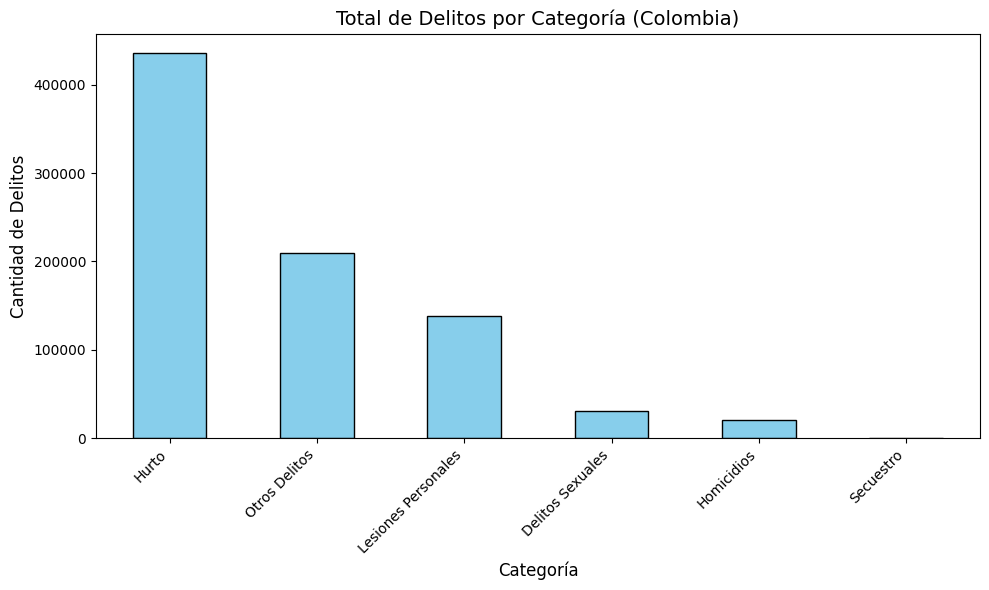

In [ ]:
import matplotlib.pyplot as plt

# Configurar estilo
plt.style.use('default')

# Gráfico de barras
categorias_total = df_delitos.groupby('CATEGORIA')['CANTIDAD'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
categorias_total.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total de Delitos por Categoría (Colombia)', fontsize=14)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Cantidad de Delitos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



###  4.3.Top 5 departamentos por tipo de delito

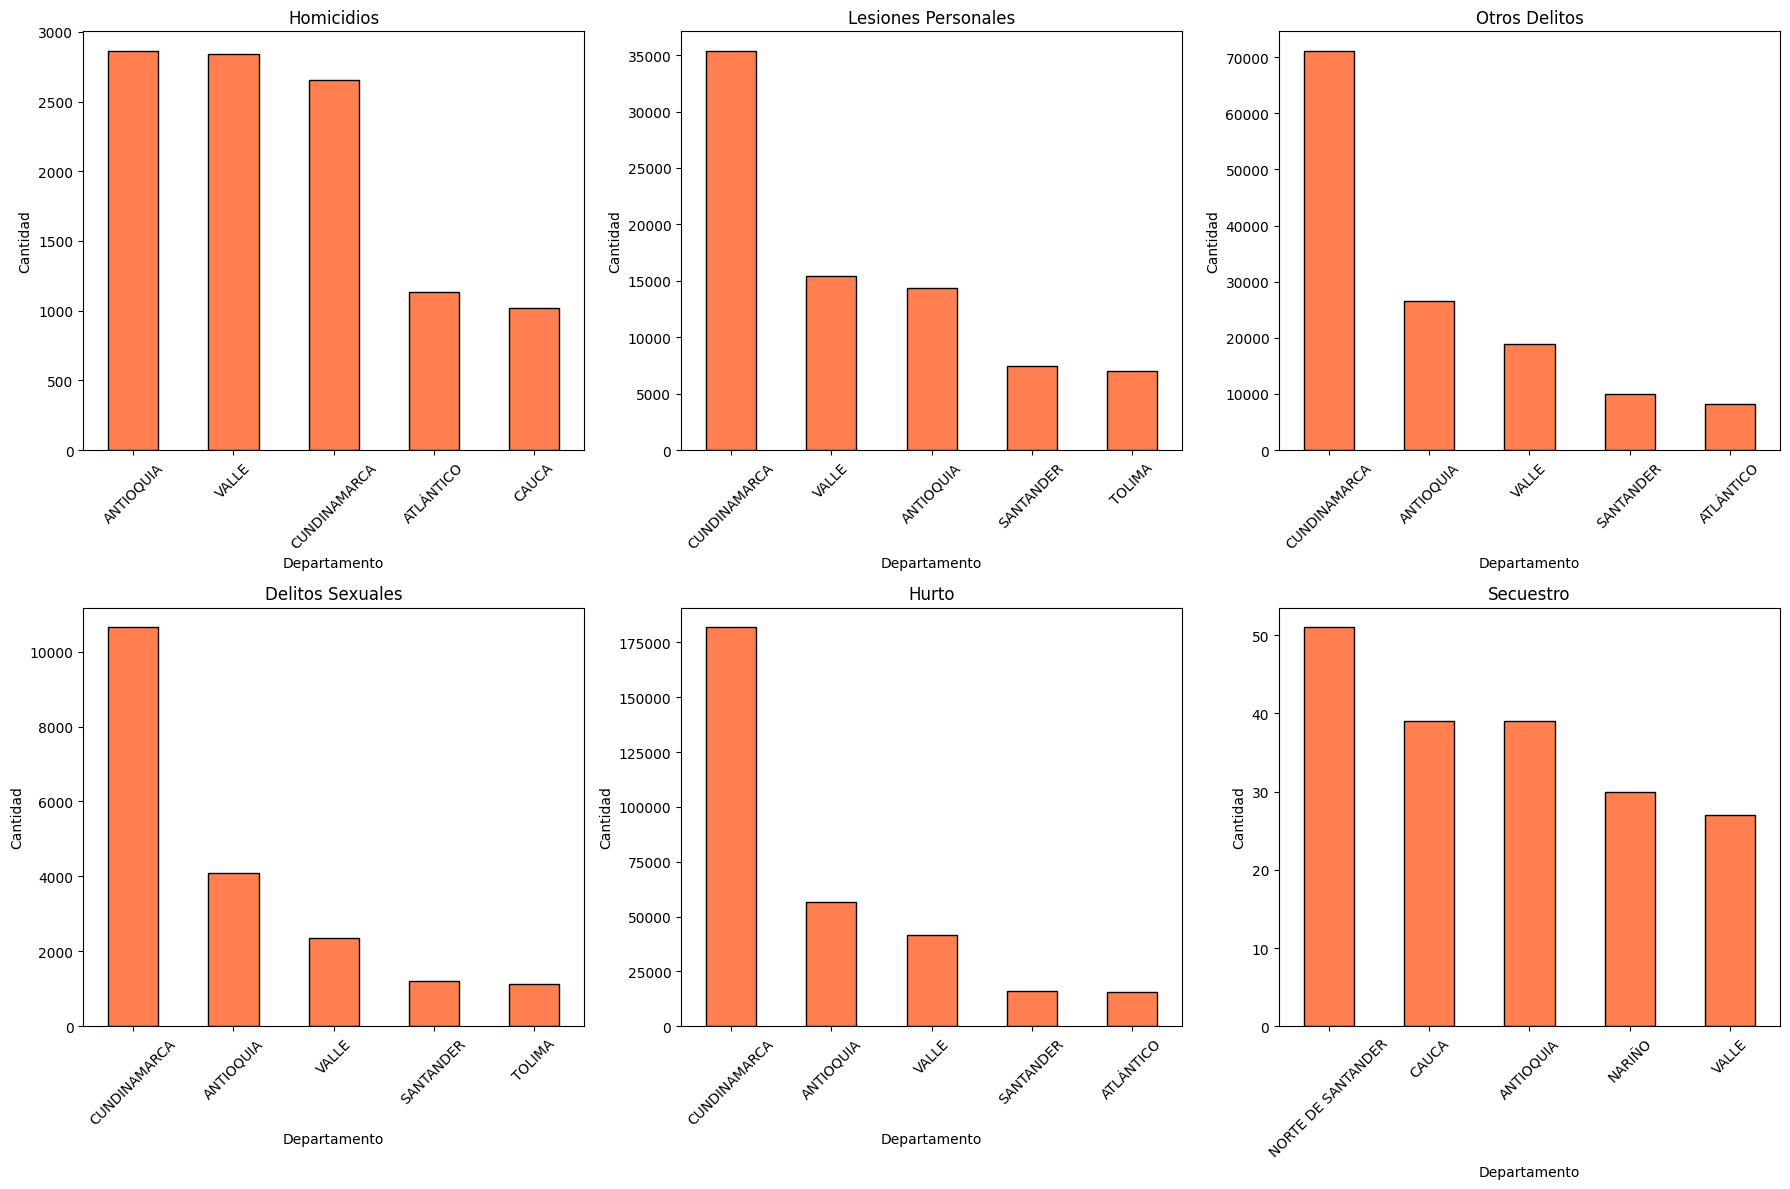

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, categoria in enumerate(df_delitos['CATEGORIA'].unique()):
    datos = df_delitos[df_delitos['CATEGORIA'] == categoria]
    top = datos.groupby('DEPARTAMENTO')['CANTIDAD'].sum().sort_values(ascending=False).head(5)

    top.plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
    axes[i].set_title(f'{categoria}', fontsize=12)
    axes[i].set_xlabel('Departamento')
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', rotation=45)

# Ocultar el último subplot si sobra
if len(df_delitos['CATEGORIA'].unique()) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### 4.4.Top 15 departamentos com mas delitos en mapa de calor

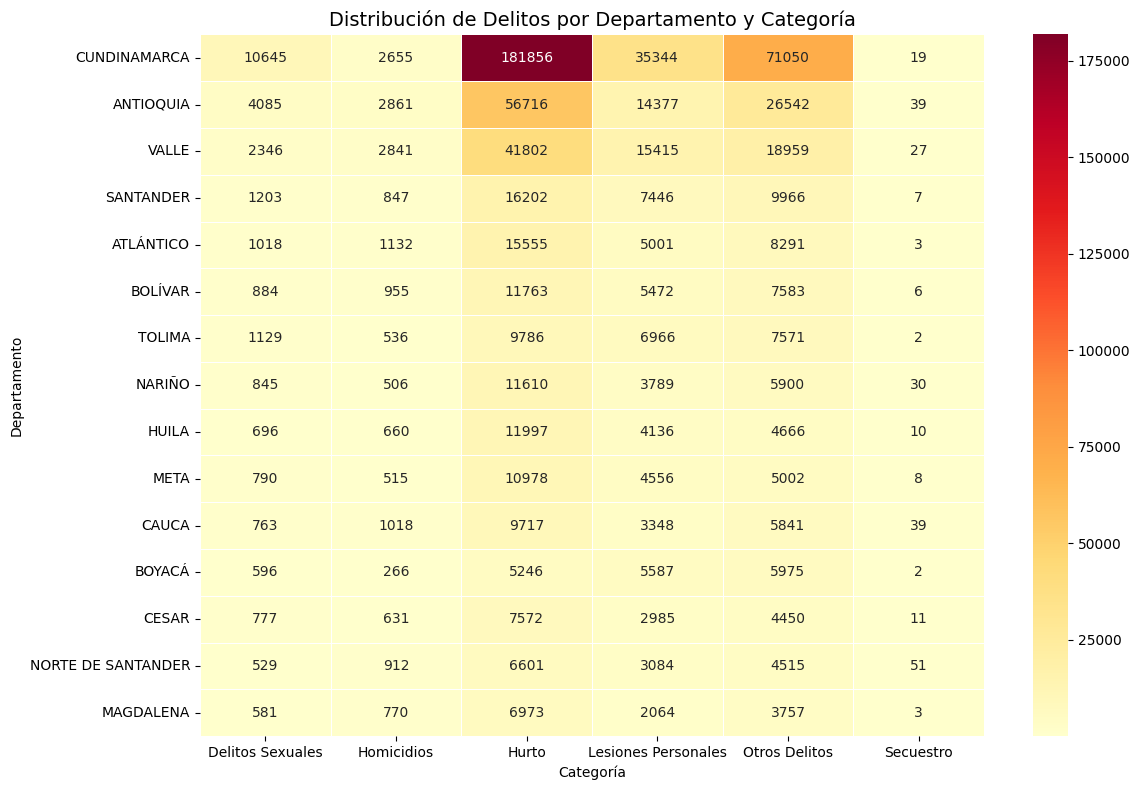

In [ ]:
matriz_delitos = df_delitos.pivot_table(
    values='CANTIDAD',
    index='DEPARTAMENTO',
    columns='CATEGORIA',
    aggfunc='sum',
    fill_value=0
)

top_deptos = matriz_delitos.sum(axis=1).sort_values(ascending=False).head(15).index
matriz_top = matriz_delitos.loc[top_deptos]

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_top, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Distribución de Delitos por Departamento y Categoría', fontsize=14)
plt.xlabel('Categoría')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

##  5.Estadisticas generales por municipios

###  5.1.Comparar municipios de ambas bases

In [ ]:
print("="*60)
print("MUNICIPIOS EN BASE DE SUICIDIOS 2024")
print("="*60)

municipios_sui = sorted(df_suicidios_2024['Municipio del hecho DANE'].unique())
print(f"Total: {len(municipios_sui)} municipios\n")

for i, mun in enumerate(municipios_sui, 1):
    print(f"{i}. {mun}")

MUNICIPIOS EN BASE DE SUICIDIOS 2024
Total: 611 municipios

1. Abejorral
2. Acacías
3. Acandí
4. Acevedo
5. Agrado
6. Agua de Dios
7. Aguachica
8. Aguadas
9. Agustín Codazzi
10. Aipe
11. Albania
12. Albán
13. Alcalá
14. Algeciras
15. Almaguer
16. Alvarado
17. Amalfi
18. Ambalema
19. Anapoima
20. Andalucía
21. Andes
22. Angelópolis
23. Anolaima
24. Anorí
25. Anserma
26. Anzoátegui
27. Anzá
28. Apartadó
29. Apía
30. Aquitania
31. Aranzazu
32. Aratoca
33. Arauca
34. Arauquita
35. Arboleda
36. Arcabuco
37. Argelia
38. Ariguaní
39. Arjona
40. Armenia
41. Armero Guayabal
42. Astrea
43. Ataco
44. Atrato
45. Ayapel
46. Balboa
47. Barbacoas
48. Barbosa
49. Barrancabermeja
50. Barrancas
51. Barranquilla
52. Becerril
53. Belalcázar
54. Bello
55. Belmira
56. Belén de Bajirá
57. Belén de Umbría
58. Betania
59. Bochalema
60. Bogotá, D.C.
61. Bojacá
62. Bojayá
63. Bolívar
64. Bosconia
65. Boyacá
66. Bucaramanga
67. Bucarasica
68. Buenaventura
69. Buenavista
70. Buesaco
71. Bugalagrande
72. Busbanzá
7

In [ ]:
print("="*60)
print(" MUNICIPIOS EN BASE DE DELITOS")
print("="*60)

# Eliminar NaN y convertir a string
municipios_del = sorted([str(m) for m in df_delitos['MUNICIPIO'].unique() if pd.notna(m)])
print(f"Total: {len(municipios_del)} municipios\n")

for i, mun in enumerate(municipios_del, 1):
    print(f"{i}. {mun}")

 MUNICIPIOS EN BASE DE DELITOS
Total: 1021 municipios

1. Abejorral
2. Abrego
3. Abriaquí
4. Acacías
5. Acandí
6. Acevedo
7. Achí
8. Agrado
9. Agua de Dios
10. Aguachica
11. Aguada
12. Aguadas
13. Aguazul
14. Agustín Codazzi
15. Aipe
16. Albania
17. Albán
18. Alcalá
19. Aldana
20. Alejandría
21. Algarrobo
22. Algeciras
23. Almaguer
24. Almeida
25. Alpujarra
26. Altamira
27. Alto Baudó
28. Altos del Rosario
29. Alvarado
30. Amagá
31. Amalfi
32. Ambalema
33. Anapoima
34. Ancuyá
35. Andalucía
36. Andes
37. Angelópolis
38. Angostura
39. Anolaima
40. Anorí
41. Anserma
42. Ansermanuevo
43. Anza
44. Anzoátegui
45. Apartadó
46. Apulo
47. Apía
48. Aquitania
49. Aracataca
50. Aranzazu
51. Aratoca
52. Arauca (CT)
53. Arauquita
54. Arbeláez
55. Arboleda
56. Arboledas
57. Arboletes
58. Arcabuco
59. Arenal
60. Argelia
61. Ariguaní
62. Arjona
63. Armenia
64. Armenia (CT)
65. Armero
66. Arroyohondo
67. Astrea
68. Ataco
69. Atrato
70. Ayapel
71. Bagadó
72. Bahía Solano
73. Bajo Baudó
74. Balboa
75. Bar

###  5.2.Obtener municipios comunes

In [ ]:
# Municipios en cada base
municipios_sui = set(df_suicidios_2024['Municipio del hecho DANE'].dropna().unique())
municipios_del = set(df_delitos['MUNICIPIO'].dropna().unique())

# Municipios que están en ambas
municipios_comunes = municipios_sui & municipios_del

print(f"Municipios en SUICIDIOS: {len(municipios_sui)}")
print(f"Municipios en DELITOS: {len(municipios_del)}")
print(f"Municipios en común: {len(municipios_comunes)}")

Municipios en SUICIDIOS: 611
Municipios en DELITOS: 1021
Municipios en común: 554


### 5.3.Filtrar base de delitos

In [ ]:
# Filtrar delitos - mantener SOLO los municipios comunes
df_delitos_filtrado = df_delitos[df_delitos['MUNICIPIO'].isin(municipios_comunes)]

print(f"Delitos originales: {len(df_delitos)}")
print(f"Delitos filtrados: {len(df_delitos_filtrado)}")

Delitos originales: 834148
Delitos filtrados: 246784


###  5.4.Filtrar la base de suicidios

In [ ]:
# Filtrar suicidios - mantener SOLO los municipios comunes
df_suicidios_filtrado = df_suicidios_2024[df_suicidios_2024['Municipio del hecho DANE'].isin(municipios_comunes)]

print(f"Suicidios originales: {len(df_suicidios_2024)}")
print(f"Suicidios filtrados: {len(df_suicidios_filtrado)}")

Suicidios originales: 3014
Suicidios filtrados: 1641


### 5.5.Verificar que ambas tienen los mismos municipios

In [ ]:
# Verificar
municipios_sui_filtrado = set(df_suicidios_filtrado['Municipio del hecho DANE'].unique())
municipios_del_filtrado = set(df_delitos_filtrado['MUNICIPIO'].unique())

print(f"\nMunicipios en SUICIDIOS filtrado: {len(municipios_sui_filtrado)}")
print(f"Municipios en DELITOS filtrado: {len(municipios_del_filtrado)}")
print(f"¿Son iguales? {municipios_sui_filtrado == municipios_del_filtrado}")


Municipios en SUICIDIOS filtrado: 554
Municipios en DELITOS filtrado: 554
¿Son iguales? True


### 5.6.Agrupar delitos filtrados por municipio y categoría

In [ ]:
# Agrupar (usando la base filtrada)
delitos_por_muni_cat = df_delitos_filtrado.groupby(['MUNICIPIO', 'CATEGORIA'])['CANTIDAD'].sum().reset_index()

print("\n Datos agrupados (solo municipios comunes):")
print(delitos_por_muni_cat.head(10))


 Datos agrupados (solo municipios comunes):
   MUNICIPIO            CATEGORIA  CANTIDAD
0  Abejorral     Delitos Sexuales      15.0
1  Abejorral           Homicidios      10.0
2  Abejorral                Hurto      48.0
3  Abejorral  Lesiones Personales      54.0
4  Abejorral        Otros Delitos      46.0
5    Acacías     Delitos Sexuales      76.0
6    Acacías           Homicidios      21.0
7    Acacías                Hurto     776.0
8    Acacías  Lesiones Personales     443.0
9    Acacías        Otros Delitos     454.0


###  5.7.Top 20 municipios con mas delitos en Colombia

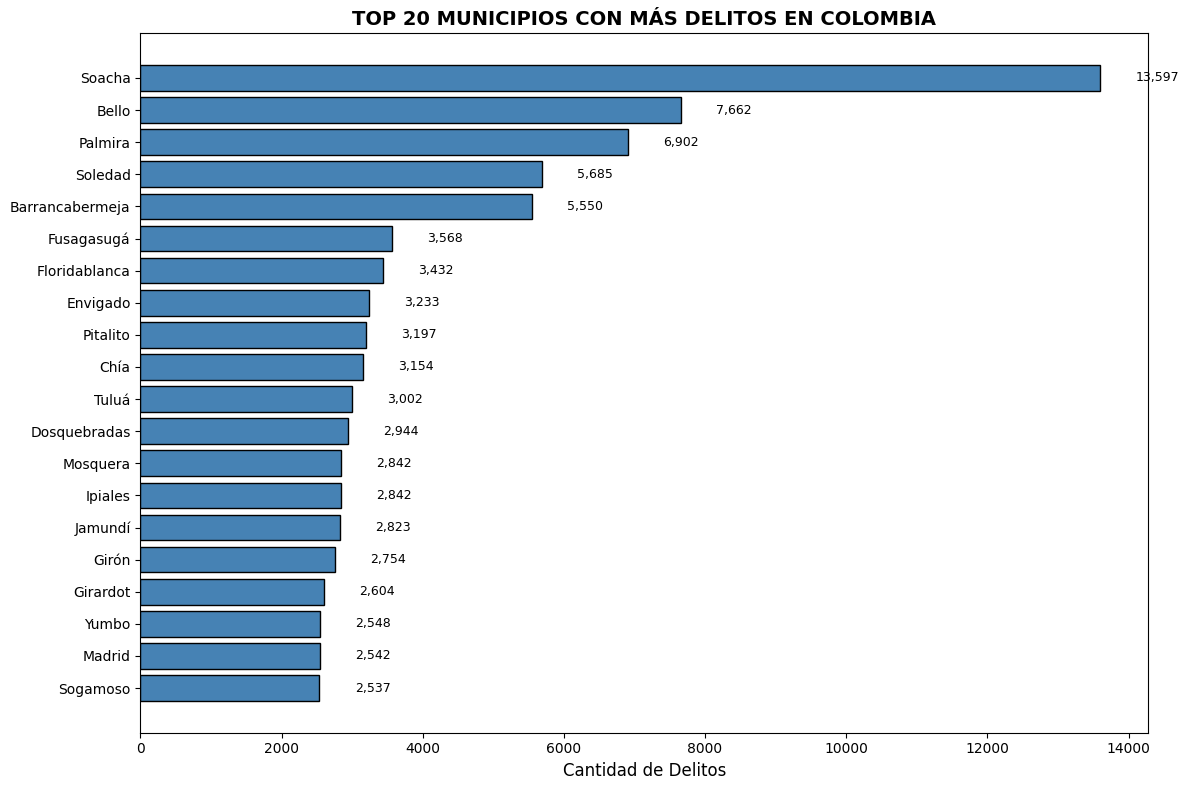

In [ ]:
import matplotlib.pyplot as plt

# Top 20 municipios con más delitos en Colombia
top20_general = delitos_por_muni_cat.groupby('MUNICIPIO')['CANTIDAD'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top20_general)), top20_general.values, color='steelblue', edgecolor='black')
plt.yticks(range(len(top20_general)), top20_general.index)
plt.xlabel('Cantidad de Delitos', fontsize=12)
plt.title('TOP 20 MUNICIPIOS CON MÁS DELITOS EN COLOMBIA', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Agregar valores
for i, (bar, val) in enumerate(zip(bars, top20_general.values)):
    plt.text(val + 500, bar.get_y() + bar.get_height()/2, f'{int(val):,}',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

###  5.8.Top 15 municipios-porcentaje total de delitos en Colombia

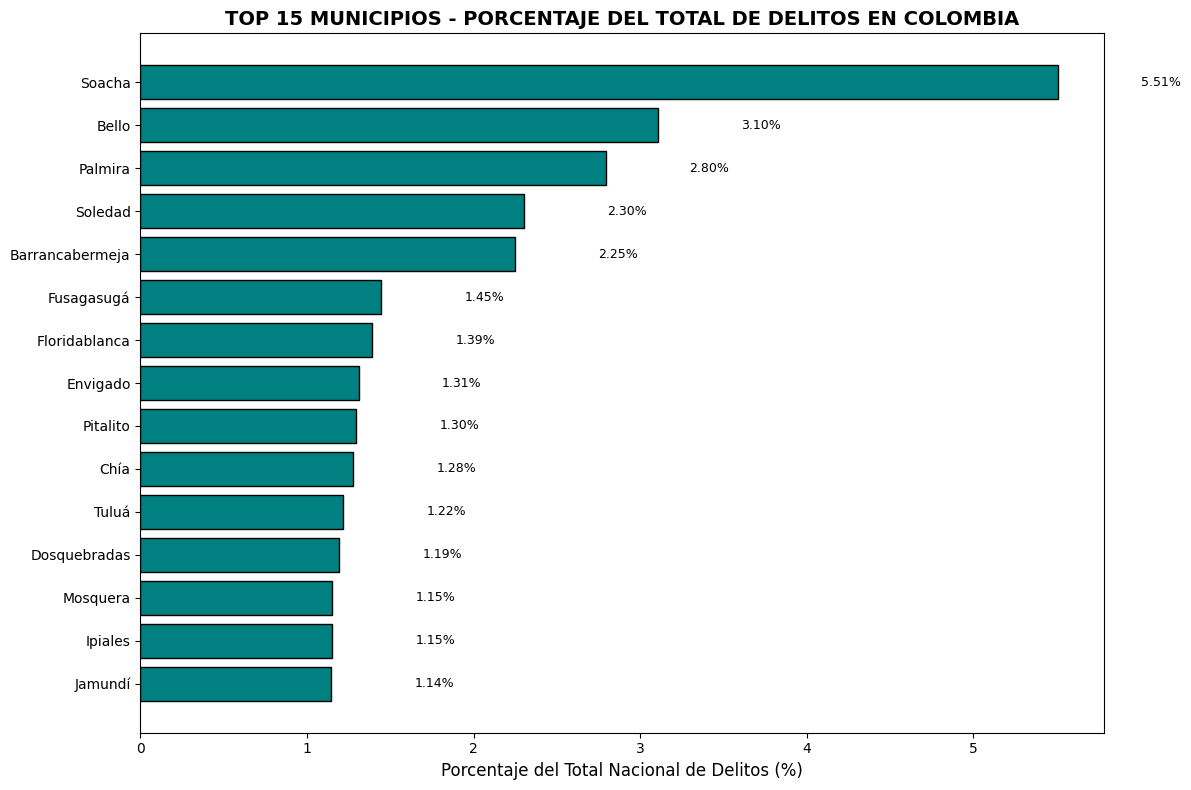


 Los 5 municipios con mayor porcentaje concentran: 15.96% de todos los delitos


In [ ]:
# Calcular porcentaje de cada municipio sobre el total nacional
total_nacional = delitos_por_muni_cat['CANTIDAD'].sum()
top15 = delitos_por_muni_cat.groupby('MUNICIPIO')['CANTIDAD'].sum().sort_values(ascending=False).head(15)
top15_porcentaje = (top15 / total_nacional) * 100

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top15_porcentaje)), top15_porcentaje.values, color='teal', edgecolor='black')
plt.yticks(range(len(top15_porcentaje)), top15_porcentaje.index)
plt.xlabel('Porcentaje del Total Nacional de Delitos (%)', fontsize=12)
plt.title('TOP 15 MUNICIPIOS - PORCENTAJE DEL TOTAL DE DELITOS EN COLOMBIA', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Agregar valores
for i, (bar, val) in enumerate(zip(bars, top15_porcentaje.values)):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.2f}%',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n Los 5 municipios con mayor porcentaje concentran: {top15_porcentaje.head(5).sum():.2f}% de todos los delitos")

### 5.9.Delitos por categoria

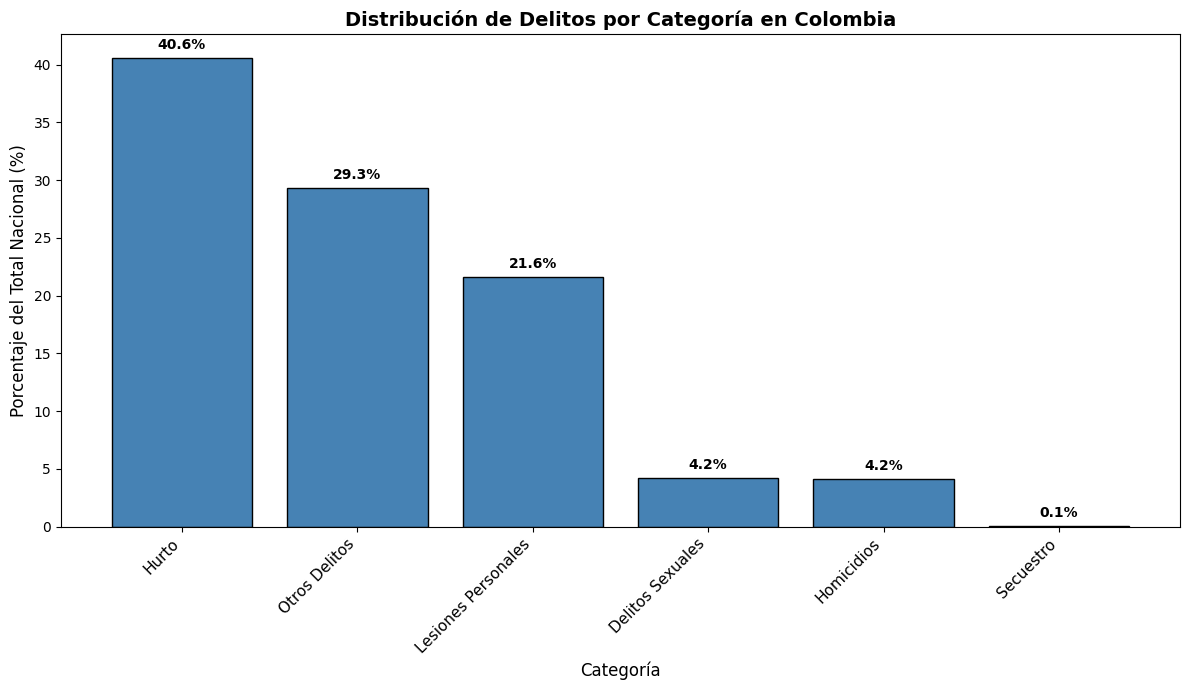

In [ ]:
import matplotlib.pyplot as plt

# Calcular porcentajes
total_nacional = df_delitos_filtrado['CANTIDAD'].sum()
porcentaje_categoria = df_delitos_filtrado.groupby('CATEGORIA')['CANTIDAD'].sum().sort_values(ascending=False)
porcentaje_categoria = (porcentaje_categoria / total_nacional) * 100

# Hacer la figura MÁS GRANDE y con mejor espacio
plt.figure(figsize=(12, 7))

# Gráfico de barras
bars = plt.bar(porcentaje_categoria.index, porcentaje_categoria.values,
               color='steelblue', edgecolor='black')

plt.title('Distribución de Delitos por Categoría en Colombia', fontsize=14, fontweight='bold')
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Porcentaje del Total Nacional (%)', fontsize=12)

# Rotar las etiquetas 45 grados y alinearlas a la derecha
plt.xticks(rotation=45, ha='right', fontsize=11)

# Agregar valores en las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Ajustar espacio para que no se corte nada
plt.tight_layout()
plt.show()

###  5.10.Top 5 municipios por categoria

In [ ]:
# Top 5 por categoría (con los datos filtrados)
for categoria in delitos_por_muni_cat['CATEGORIA'].unique():
    top = delitos_por_muni_cat[delitos_por_muni_cat['CATEGORIA'] == categoria]
    top = top.sort_values('CANTIDAD', ascending=False).head(5)
    print(f"\n{'='*50}")
    print(f"TOP 5 MUNICIPIOS - {categoria}")
    print('='*50)
    for i, row in top.iterrows():
        print(f"{row['MUNICIPIO']}: {int(row['CANTIDAD']):,} delitos")


TOP 5 MUNICIPIOS - Delitos Sexuales
Soacha: 395 delitos
Bello: 327 delitos
Soledad: 199 delitos
Barrancabermeja: 194 delitos
Tuluá: 176 delitos

TOP 5 MUNICIPIOS - Homicidios
Soledad: 261 delitos
Soacha: 241 delitos
Barrancabermeja: 235 delitos
Palmira: 210 delitos
Santander de Quilichao: 140 delitos

TOP 5 MUNICIPIOS - Hurto
Soacha: 6,273 delitos
Bello: 3,914 delitos
Palmira: 3,464 delitos
Soledad: 3,040 delitos
Chía: 2,070 delitos

TOP 5 MUNICIPIOS - Lesiones Personales
Soacha: 2,070 delitos
Palmira: 1,480 delitos
Barrancabermeja: 917 delitos
Fusagasugá: 916 delitos
Bello: 894 delitos

TOP 5 MUNICIPIOS - Otros Delitos
Soacha: 4,617 delitos
Bello: 2,401 delitos
Barrancabermeja: 2,271 delitos
Palmira: 1,596 delitos
Soledad: 1,493 delitos

TOP 5 MUNICIPIOS - Secuestro
Ipiales: 6 delitos
Villa del Rosario: 6 delitos
Tame: 6 delitos
Tibú: 6 delitos
Bello: 5 delitos


### 5.11.Graficos d top 5 municipios por categoria

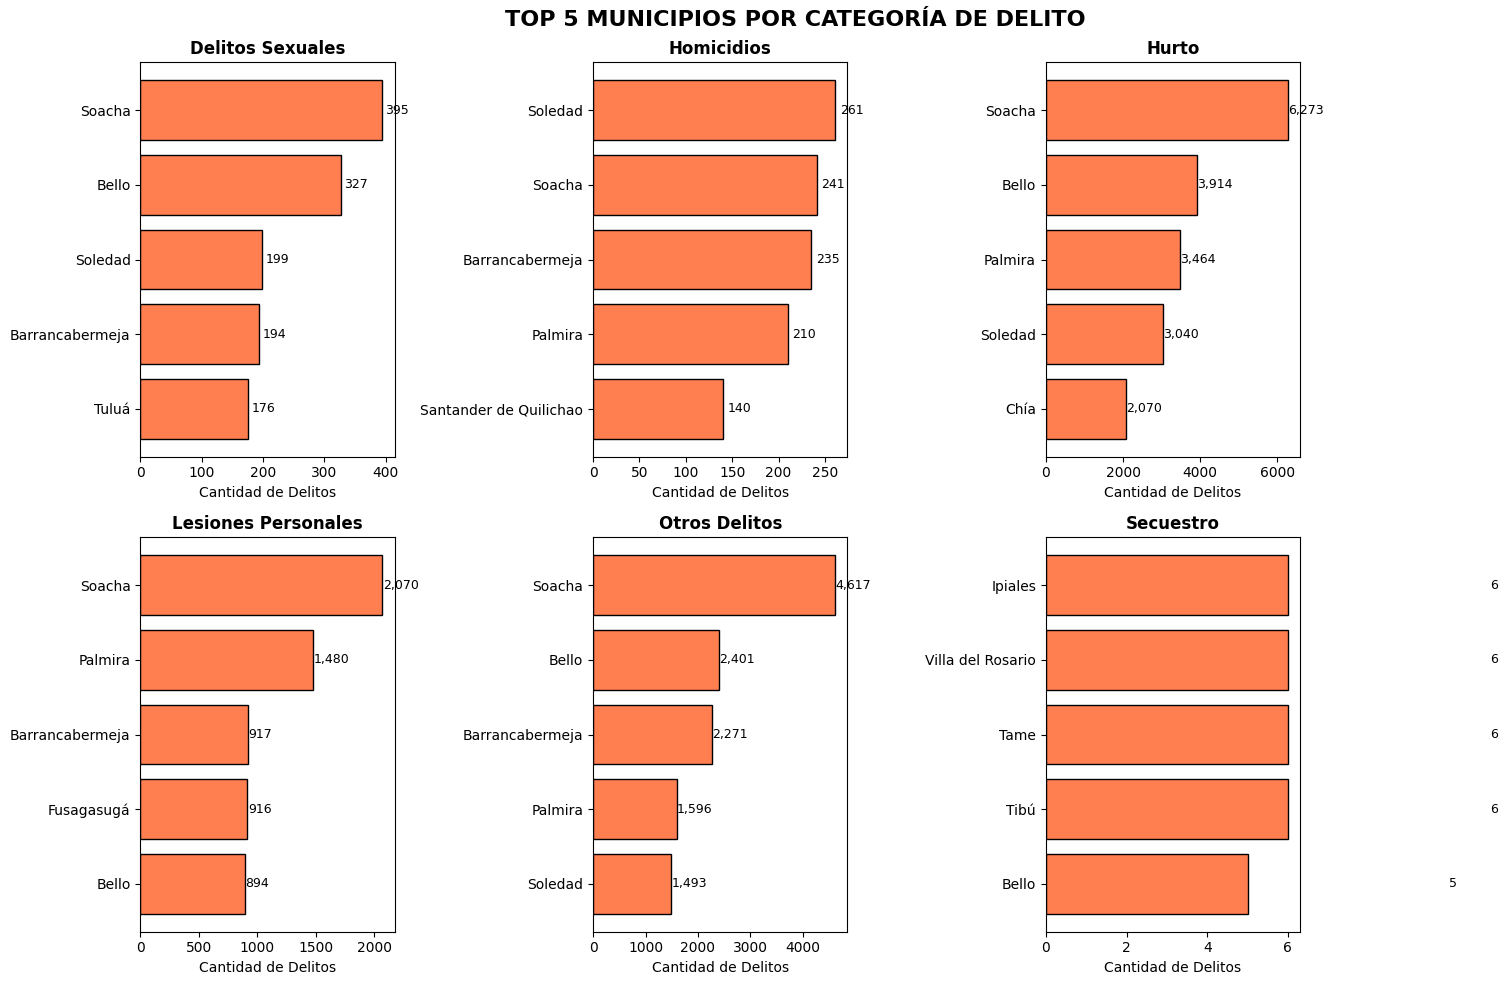

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Preparar datos
categorias = delitos_por_muni_cat['CATEGORIA'].unique()
top_municipios = ['Soacha', 'Bello', 'Soledad', 'Barrancabermeja', 'Palmira']

# Crear matriz de datos
datos = {}
for cat in categorias:
    top = delitos_por_muni_cat[delitos_por_muni_cat['CATEGORIA'] == cat]
    top = top.sort_values('CANTIDAD', ascending=False).head(5)
    datos[cat] = {row['MUNICIPIO']: row['CANTIDAD'] for _, row in top.iterrows()}

# Configurar gráfico
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, cat in enumerate(categorias):
    municipios = list(datos[cat].keys())
    valores = list(datos[cat].values())

    # Barras horizontales
    bars = axes[i].barh(municipios, valores, color='coral', edgecolor='black')
    axes[i].set_title(f'{cat}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cantidad de Delitos')
    axes[i].invert_yaxis()

    # Agregar valores
    for bar, val in zip(bars, valores):
        axes[i].text(val + 5, bar.get_y() + bar.get_height()/2, f'{int(val):,}',
                    va='center', fontsize=9)

# Ocultar subplot sobrante
if len(categorias) < 6:
    axes[-1].set_visible(False)

plt.suptitle('TOP 5 MUNICIPIOS POR CATEGORÍA DE DELITO', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

###  5.12.Top 10 municipios con mas delitos mapa de calor

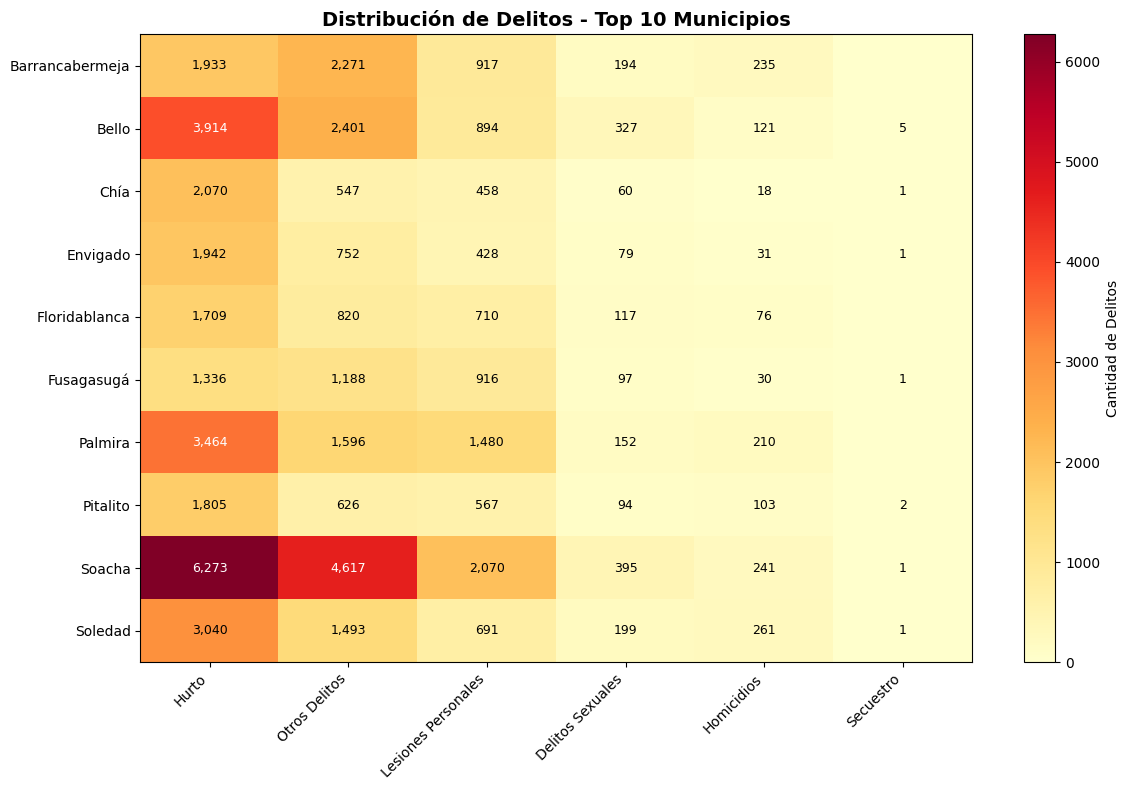

In [ ]:
# Top 10 municipios con más delitos totales
top10_municipios = delitos_por_muni_cat.groupby('MUNICIPIO')['CANTIDAD'].sum().sort_values(ascending=False).head(10).index

# Filtrar datos
top10_datos = delitos_por_muni_cat[delitos_por_muni_cat['MUNICIPIO'].isin(top10_municipios)]

# Pivotar
pivot_top10 = top10_datos.pivot(index='MUNICIPIO', columns='CATEGORIA', values='CANTIDAD').fillna(0)

# Reordenar columnas
orden_cats = ['Hurto', 'Otros Delitos', 'Lesiones Personales', 'Delitos Sexuales', 'Homicidios', 'Secuestro']
pivot_top10 = pivot_top10[orden_cats]

# Mapa de calor
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(pivot_top10.values, cmap='YlOrRd', aspect='auto')

# Configurar ejes
ax.set_xticks(range(len(pivot_top10.columns)))
ax.set_xticklabels(pivot_top10.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot_top10.index)))
ax.set_yticklabels(pivot_top10.index)
ax.set_title('Distribución de Delitos - Top 10 Municipios', fontsize=14, fontweight='bold')

# Agregar valores en celdas
for i in range(len(pivot_top10.index)):
    for j in range(len(pivot_top10.columns)):
        val = pivot_top10.values[i, j]
        if val > 0:
            text_color = 'white' if val > pivot_top10.values.max() / 2 else 'black'
            ax.text(j, i, f'{int(val):,}', ha='center', va='center',
                   color=text_color, fontsize=9)

plt.colorbar(im, ax=ax, label='Cantidad de Delitos')
plt.tight_layout()
plt.show()